In [17]:
import yfinance as yf
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

In [18]:
spy = yf.Ticker("SPY")   # SPDR S&P 500 ETF
voo = yf.Ticker("VOO")   # Vanguard S&P 500 ETF
ivv = yf.Ticker("IVV")   # iShares Core S&P 500 ETF

In [19]:
data = yf.download("SPY", start="2020-01-01", auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


In [20]:
# closing price only
spy_close = data["Close"]
spy_close.columns.name = None   # drop the "Ticker" column label
spy_close = spy_close.rename(columns={"SPY": "close"})
spy_close.tail()

,close
Date,
2026-09-09,762.400024
2026-09-10,757.830017
2026-09-11,764.289978
2026-09-14,760.880005
2026-09-15,757.390015


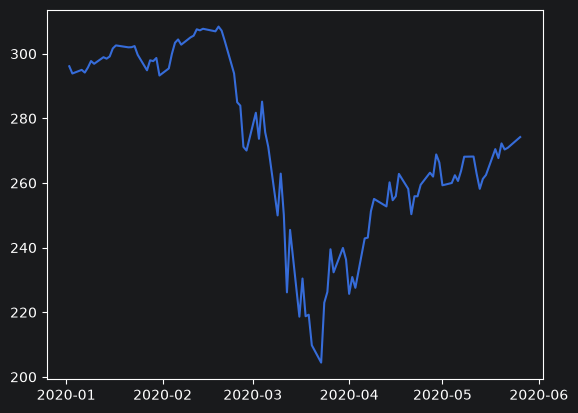

In [21]:
plt.plot(spy_close[:100])

In [22]:
# 1. moving average and standard deviation of the trailing window (historical, excludes today)
window = 7
num_std = 1

sig = spy_close.copy()
sig["ma"] = sig["close"].rolling(window).mean().shift(1)
sig["std"] = sig["close"].rolling(window).std().shift(1)
sig["upper"] = sig["ma"] + num_std * sig["std"]
sig["lower"] = sig["ma"] - num_std * sig["std"]

# 2. is today's close outside the historical range?
sig["signal"] = 0
sig.loc[sig["close"] < sig["lower"], "signal"] = 1    # underpriced -> buy now, sell tomorrow
sig.loc[sig["close"] > sig["upper"], "signal"] = -1   # overpriced  -> sell now, buy tomorrow
sig = sig.dropna()

sig["signal"].value_counts()

signal
-1    663
 0    658
 1    356
Name: count, dtype: int64

In [23]:
# 3/4. each signal is a one-day trade: enter at today's close, exit at tomorrow's close
starting_cash = 10_000

trades = sig[["close", "signal"]].copy()
trades["exit_close"] = trades["close"].shift(-1)
trades = trades.dropna()

equity = starting_cash
rows = []
for date, row in trades.iterrows():
    shares = 0
    pnl = 0.0
    if row["signal"] != 0:
        shares = int(equity // row["close"])                            # size with all available equity
        pnl = row["signal"] * shares * (row["exit_close"] - row["close"])  # long: exit-entry, short: entry-exit
        equity += pnl
    rows.append({"signal": row["signal"], "entry": row["close"], "exit": row["exit_close"],
                 "shares": shares, "trade_pnl": pnl, "equity": equity})

portfolio = pd.DataFrame(rows, index=trades.index)
portfolio["pnl"] = portfolio["equity"] - starting_cash
portfolio["side"] = portfolio["signal"].map({1: "long", -1: "short", 0: ""})
portfolio[portfolio["signal"] != 0].tail(10)

,signal,entry,exit,shares,trade_pnl,equity,pnl,side
Date,,,,,,,,
2026-08-19,1.0,769.059998,762.599976,17,-109.820374,12964.747574,2964.747574,long
2026-08-20,1.0,762.599976,765.719971,17,53.039917,13017.787491,3017.787491,long
2026-08-21,1.0,765.719971,763.469971,17,-38.250000,12979.537491,2979.537491,long
2026-08-24,1.0,763.469971,765.909973,17,41.480042,13021.017532,3021.017532,long
2026-08-27,-1.0,771.099976,769.349976,16,28.000000,13049.017532,3049.017532,short
2026-08-28,-1.0,769.349976,767.049988,16,36.799805,13085.817337,3085.817337,short
2026-09-01,1.0,761.780029,765.159973,17,57.459045,13143.276382,3143.276382,long
2026-09-03,-1.0,773.169983,770.190002,16,47.679688,13190.956070,3190.956070,short
2026-09-09,1.0,762.400024,757.830017,17,-77.690125,13113.265945,3113.265945,long


In [24]:
done = portfolio[portfolio["signal"] != 0]
wins = done[done["trade_pnl"] > 0]
daily_ret = portfolio["equity"].pct_change().dropna()
drawdown = portfolio["equity"] / portfolio["equity"].cummax() - 1
buy_hold = starting_cash * (portfolio.index.map(sig["close"])[-1] / sig["close"].iloc[0])

print(f"starting cash:   ${starting_cash:,.2f}")
print(f"final equity:    ${portfolio['equity'].iloc[-1]:,.2f}  ({portfolio['pnl'].iloc[-1] / starting_cash:+.2%})")
print(f"buy & hold:      ${buy_hold:,.2f}  ({buy_hold / starting_cash - 1:+.2%})")
print(f"trades:          {len(done)}  (long {int((done['signal'] == 1).sum())}, short {int((done['signal'] == -1).sum())})")
print(f"win rate:        {len(wins) / len(done):.1%}")
print(f"avg trade pnl:   ${done['trade_pnl'].mean():,.2f}")
print(f"  long avg:      ${done.loc[done['signal'] == 1, 'trade_pnl'].mean():,.2f}")
print(f"  short avg:     ${done.loc[done['signal'] == -1, 'trade_pnl'].mean():,.2f}")
print(f"max drawdown:    {drawdown.min():.2%}")
print(f"sharpe (daily):  {daily_ret.mean() / daily_ret.std() * np.sqrt(252):.2f}")

starting cash:   $10,000.00
final equity:    $13,223.09  (+32.23%)
buy & hold:      $25,453.21  (+154.53%)
trades:          1018  (long 355, short 663)
win rate:        49.1%
avg trade pnl:   $3.17
  long avg:      $20.47
  short avg:     $-6.10
max drawdown:    -15.18%
sharpe (daily):  0.36


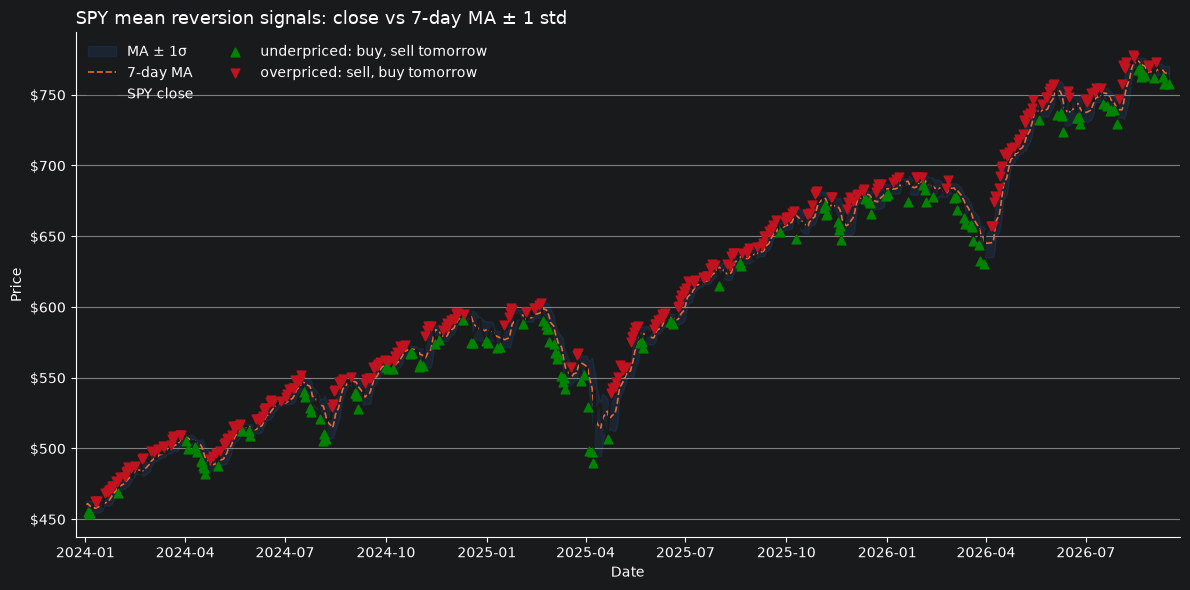

In [25]:
plot = sig.loc["2024-01-01":]

fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(plot.index, plot["lower"], plot["upper"], color="#2a78d6", alpha=0.12, label=f"MA ± {num_std}σ")
ax.plot(plot.index, plot["ma"], color="#eb6834", linewidth=1.2, linestyle="--", label=f"{window}-day MA")
ax.plot(plot.index, plot["close"], color="#1a1a19", linewidth=1.6, label="SPY close")

under, over = plot[plot["signal"] == 1], plot[plot["signal"] == -1]
ax.scatter(under.index, under["close"], marker="^", s=40, color="#008300", zorder=3, label="underpriced: buy, sell tomorrow")
ax.scatter(over.index, over["close"], marker="v", s=40, color="#c1121f", zorder=3, label="overpriced: sell, buy tomorrow")

ax.set_title(f"SPY mean reversion signals: close vs {window}-day MA ± {num_std} std", fontsize=13, loc="left")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("${x:,.0f}"))
ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left", frameon=False, ncol=2)
ax.margins(x=0.01)
fig.tight_layout()
plt.show()

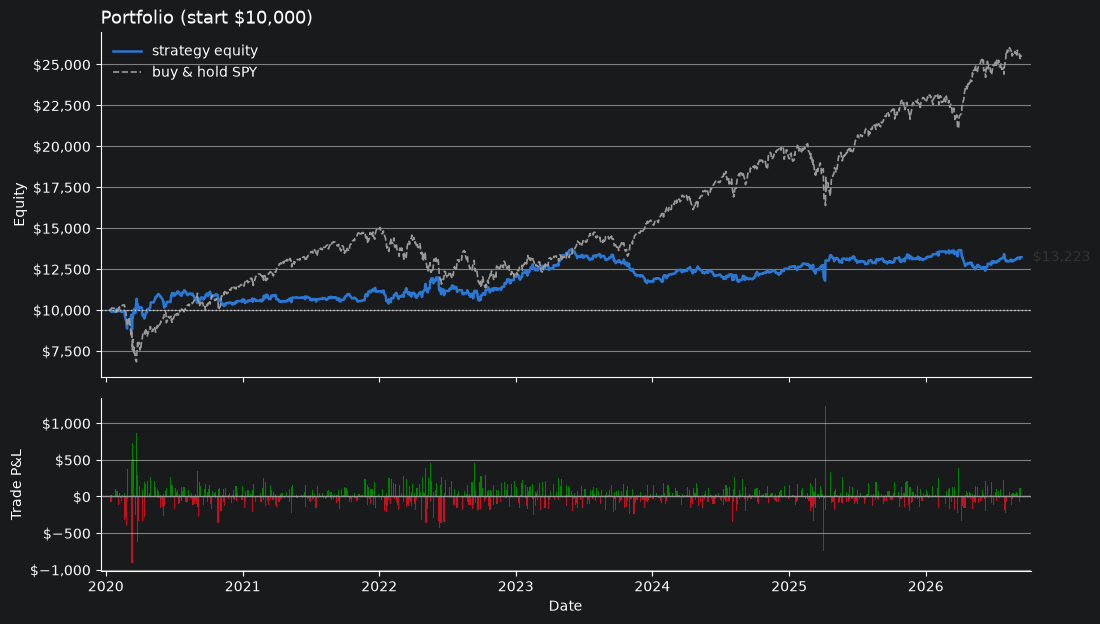

In [26]:
bh = starting_cash * sig["close"].loc[portfolio.index] / sig["close"].loc[portfolio.index].iloc[0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08})

ax1.plot(portfolio.index, portfolio["equity"], color="#2a78d6", linewidth=1.8, label="strategy equity")
ax1.plot(bh.index, bh, color="#999999", linewidth=1.2, linestyle="--", label="buy & hold SPY")
ax1.axhline(starting_cash, color="#cccccc", linewidth=1, linestyle=":")
ax1.annotate(f"${portfolio['equity'].iloc[-1]:,.0f}", xy=(portfolio.index[-1], portfolio["equity"].iloc[-1]),
             xytext=(8, 0), textcoords="offset points", va="center", fontsize=10, color="#333333")
ax1.set_title("Portfolio (start $10,000)", fontsize=13, loc="left")
ax1.set_ylabel("Equity")
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("${x:,.0f}"))
ax1.legend(loc="upper left", frameon=False)

colors = np.where(done["trade_pnl"] >= 0, "#008300", "#c1121f")
ax2.bar(done.index, done["trade_pnl"], color=colors, width=3)
ax2.axhline(0, color="#999999", linewidth=1)
ax2.set_ylabel("Trade P&L")
ax2.set_xlabel("Date")
ax2.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("${x:,.0f}"))

for ax in (ax1, ax2):
    ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.margins(x=0.01)

plt.show()